# *Kapitel 4 - Koduppgifter*

## **11. classification_report**

In [1]:
from sklearn.metrics import classification_report

In [2]:
y_true = [0, 1, 2, 2, 2]

In [3]:
y_pred = [0, 0, 2, 2, 1]

In [4]:
target_names = ["class 0", "class 1", "class 2"]

In [5]:
print(classification_report(y_true, y_pred, target_names=target_names))

              precision    recall  f1-score   support

     class 0       0.50      1.00      0.67         1
     class 1       0.00      0.00      0.00         1
     class 2       1.00      0.67      0.80         3

    accuracy                           0.60         5
   macro avg       0.50      0.56      0.49         5
weighted avg       0.70      0.60      0.61         5



Koden använder classification_report från scikit-learn för att sammanfatta hur bra en klassificeringsmodell har presterat. y_true innehåller de verkliga klasserna och y_pred innehåller modellens prediktioner. target_names används för att ge klasserna namnen class 0, class 1 och class 2. classification_report beräknar bland annat precision, recall och F1-score för varje klass samt accuracy för hela modellen. Scikit-learn
Modellen får 60 % accuracy, eftersom den klassificerar 3 av 5 observationer rätt.

För class 0 är precisionen 0,50 och recall 1,00. Det betyder att modellen hittar den enda riktiga class 0-observationen, men att hälften av de observationer som modellen förutsäger som class 0 egentligen inte är class 0.

För class 1 är både precision och recall 0,00. Modellen lyckas alltså inte hitta den riktiga class 1-observationen och har inte heller någon korrekt positiv prediktion för class 1.

För class 2 är precisionen 1,00 och recall 0,67. Det betyder att alla observationer som modellen förutsäger som class 2 faktiskt är class 2, men modellen hittar bara två av de tre riktiga class 2-observationerna.
F1-score blir 0,67 för class 0, 0,00 för class 1 och 0,80 för class 2. 

Sammantaget fungerar modellen bäst för class 2 och sämst för class 1.
Resultatet visar därför också varför det är viktigt att inte bara titta på accuracy. Modellen får 60 % accuracy, men presterar väldigt olika bra för de olika klasserna.

## **13. hr_employee_data**

In [6]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [7]:
df = pd.read_excel("dataset/hr_employee_data.xlsx")

In [8]:
X = df.drop(columns=["left", "Emp_Id"])
y = df["left"]

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns
numeric_features = X.select_dtypes(exclude=["object"]).columns

In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ],
    remainder="passthrough",
)

In [12]:
model = RandomForestClassifier(n_estimators=100, random_state=42)

In [13]:
pipeline = Pipeline([("preprocessor", preprocessor), ("model", model)])

In [14]:
pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

In [15]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9903333333333333

Confusion matrix:
[[2283    3]
 [  26  688]]

Classification report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       1.00      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



### **Tolkning av resultatet**

Modellen får en accuracy på ungefär 99 %, vilket innebär att den klassificerar nästan alla observationer i testdatan rätt. Confusion matrix visar att modellen klassificerar 2283 personer som stannat kvar korrekt och 688 personer som lämnat företaget korrekt. Modellen gör samtidigt 3 false positives och 26 false negatives.

För class 1, alltså anställda som har lämnat företaget, är recall 0,96. Det betyder att modellen hittar ungefär 96 % av de personer som faktiskt har lämnat företaget. Precisionen är 1,00, vilket innebär att de personer som modellen förutspår har lämnat företaget i princip alltid tillhör class 1 i denna testdata.

Resultatet visar att modellen presterar mycket bra på denna testuppsättning. Samtidigt är det viktigt att komma ihåg att resultatet gäller just denna data och denna uppdelning mellan träningsdata och testdata.

## **Koduppgift 15 - MNIST**

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.ensemble import VotingClassifier

from PIL import Image

def display_confusion_matrix(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm).plot()

In [17]:
mnist = fetch_openml("mnist_784", version=1, cache=True, as_frame=False)
X = mnist["data"][:10000]
y = mnist["target"][:10000].astype(np.uint8)

print(X.shape)
print(y.shape)

(10000, 784)
(10000,)


True label for the plotted image is 5


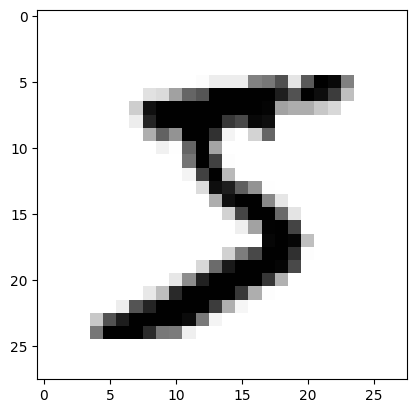

In [18]:
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
print("True label for the plotted image is", y[0])

# print(mnist.DESCR)

In [19]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=2000, random_state=42
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=2000, random_state=42
)

# Scaling data
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [20]:
# Model training
logreg_clf = LogisticRegression(max_iter=1000)
random_forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
extra_trees_clf = ExtraTreesClassifier(n_estimators=100, random_state=42)

named_estimators = [
    ("logreg_clf", logreg_clf),
    ("random_forest_clf", random_forest_clf),
    ("extra_trees_clf", extra_trees_clf),
]
voting_clf = VotingClassifier(named_estimators, voting="hard")

models = [logreg_clf, random_forest_clf, extra_trees_clf, voting_clf]
for model in models:
    model.fit(X_train, y_train)

print("Accuracy for each model")
model_names = [
    "Logistic Regression",
    "Random Forest",
    "Extra Trees",
    "Voting Classifier",
]
for name, model in zip(model_names, models):
    score = model.score(X_val, y_val)
    print(f"{name:20s}: {score:.4f}")

Accuracy for each model
Logistic Regression : 0.8800
Random Forest       : 0.9380
Extra Trees         : 0.9400
Voting Classifier   : 0.9395


              precision    recall  f1-score   support

           0       0.98      0.98      0.98       217
           1       0.99      0.98      0.98       217
           2       0.91      0.92      0.91       190
           3       0.94      0.89      0.92       218
           4       0.96      0.92      0.94       215
           5       0.95      0.89      0.92       160
           6       0.95      0.98      0.96       197
           7       0.94      0.93      0.94       210
           8       0.91      0.95      0.93       183
           9       0.88      0.95      0.91       193

    accuracy                           0.94      2000
   macro avg       0.94      0.94      0.94      2000
weighted avg       0.94      0.94      0.94      2000



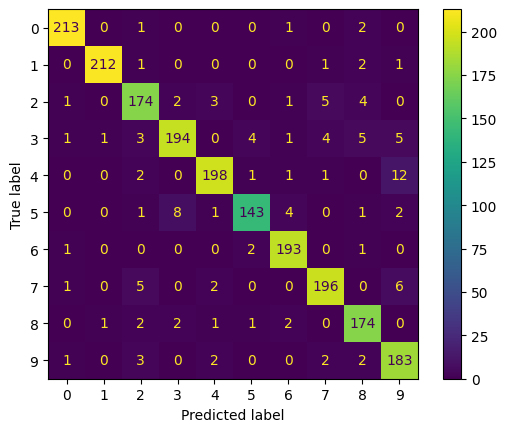

In [21]:
et_pred_val = extra_trees_clf.predict(X_val)

display_confusion_matrix(y_val, et_pred_val)
print(classification_report(y_val, et_pred_val))

In [22]:
X_train_val = scaler.fit_transform(X_train_val)
extra_trees_clf.fit(X_train_val, y_train_val)

et_pred_test = extra_trees_clf.predict(X_test)
# display_confusion_matrix(y_test, et_pred_test)
# print(classification_report(y_test, et_pred_test))

In [23]:
scaler_2 = StandardScaler()
X = scaler_2.fit_transform(X)
extra_trees_clf.fit(X, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls 3 sources of randomness:- the bootstrapping of the samples used when building trees (if ``bootstrap=True``)- the sampling of the features to consider when looking for the best split at each node (if ``max_features < n_features``)- the draw of the splits for each of the `max_features`See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` 

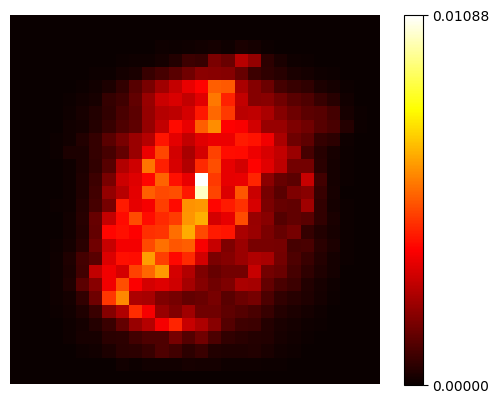

In [24]:
def plot_digit(data):
    image = data.reshape(28, 28)
    plt.imshow(image, cmap=mpl.cm.hot, interpolation="nearest")
    plt.axis("off")


plot_digit(extra_trees_clf.feature_importances_)

cbar = plt.colorbar(
    ticks=[
        extra_trees_clf.feature_importances_.min(),
        extra_trees_clf.feature_importances_.max(),
    ]
)

In [25]:
# Ladda din egen bild
img = Image.open("bilder/number7.png")

img = img.convert("L")
img = img.resize((28, 28))


img_array = np.array(img).astype(np.float64)
img_flat = img_array.reshape(1, -1)
img_scaled = scaler_2.transform(img_flat)

prediction = extra_trees_clf.predict(img_scaled)
print(f"Modellen tror det är siffran: {prediction[0]}")

Modellen tror det är siffran: 7


In [26]:
from joblib import dump

dump(extra_trees_clf, "extra_trees_mnist.joblib")
dump(scaler_2, "mnist_scaler.joblib")

['mnist_scaler.joblib']

### **Kort sammanfattning och information**

För att testa modellen på bilder som inte kommer från MNIST-datasetet använde jag några externa bilder på handskrivna siffror. Eftersom bilderna var i olika storlekar bearbetade jag dem på samma sätt som i kodexemplet ovan. Bilderna gjordes om till gråskala och ändrades till 28 × 28 pixlar innan de skickades till modellen.

Modellen lyckades känna igen siffrorna 0–9, förutom en lite svårare bild på siffran 9. Resultatet visar att modellen även kan användas för att försöka känna igen handskrivna siffror från andra bilder än de som finns i MNIST-datasetet. Samtidigt kan resultatet påverkas av exempelvis hur siffran är skriven och hur bilden är utformad.

Som ett tillägg gjorde jag även en liten Streamlit-applikation där man kan ladda upp en bild och låta modellen försöka känna igen vilken siffra bilden innehåller. Applikationen finns i filen `app.py` och bilderna som används för testning finns i mappen `bilder`.

För att starta Streamlit-applikationen öppnar jag terminalen i projektets rotmapp och går först till mappen för Kapitel 4:

```bash
cd "Kapitel 4"
```

Därefter startas applikationen med:

```bash
streamlit run app.py